# TUGAS MACHINE LEARNING
## Sampling dan Exploratory Data Analysis (EDA)
Dataset: Iris

Nama: Indah Sari Kurniawati
NIM: 2304010014
Tanggal: 27 Februari 2026

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris

plt.style.use('seaborn-v0_8')

In [18]:
iris = load_iris()

df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target

df['species'] = df['species'].map({
    0: 'setosa',
    1: 'versicolor',
    2: 'virginica'
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# BAGIAN A – Eksplorasi Data Awal

In [19]:
print("Jumlah data:", df.shape[0])
print("Jumlah variabel:", df.shape[1])
print("\nTipe Data:")
print(df.dtypes)

print("\nJumlah masing-masing spesies:")
print(df['species'].value_counts())

Jumlah data: 150
Jumlah variabel: 5

Tipe Data:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                  str
dtype: object

Jumlah masing-masing spesies:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [20]:
mean = df.mean(numeric_only=True)
median = df.median(numeric_only=True)
std = df.std(numeric_only=True)
min_val = df.min(numeric_only=True)
max_val = df.max(numeric_only=True)

stats = pd.DataFrame({
    "Mean": mean,
    "Median": median,
    "Std Dev": std,
    "Min": min_val,
    "Max": max_val
})

stats

,Mean,Median,Std Dev,Min,Max
sepal length (cm),5.843333,5.80,0.828066,4.3,7.9
sepal width (cm),3.057333,3.00,0.435866,2.0,4.4
petal length (cm),3.758000,4.35,1.765298,1.0,6.9
petal width (cm),1.199333,1.30,0.762238,0.1,2.5


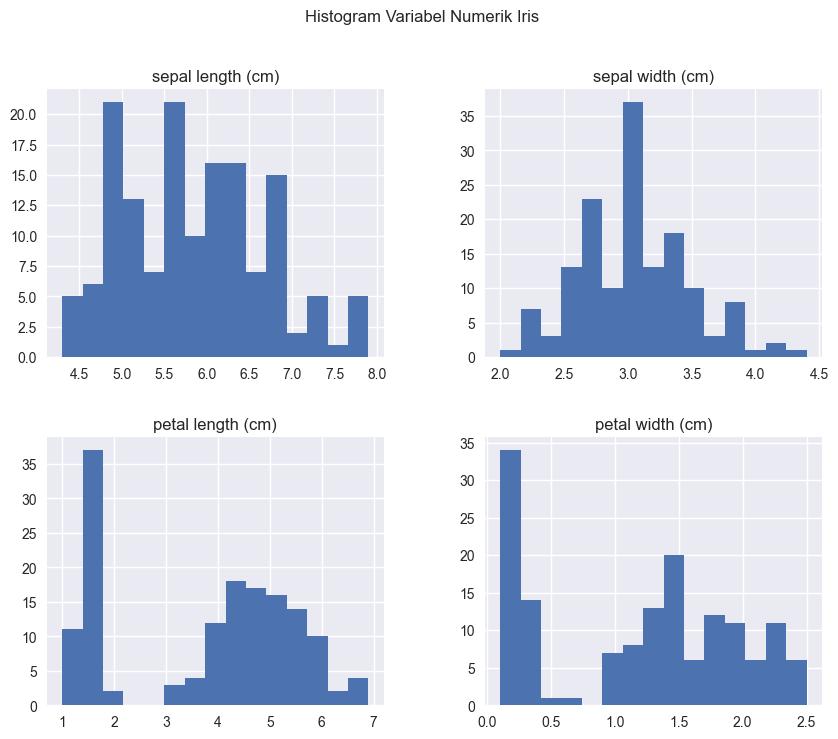

In [21]:
df.iloc[:, :4].hist(figsize=(10,8), bins=15)
plt.suptitle("Histogram Variabel Numerik Iris")
plt.show()

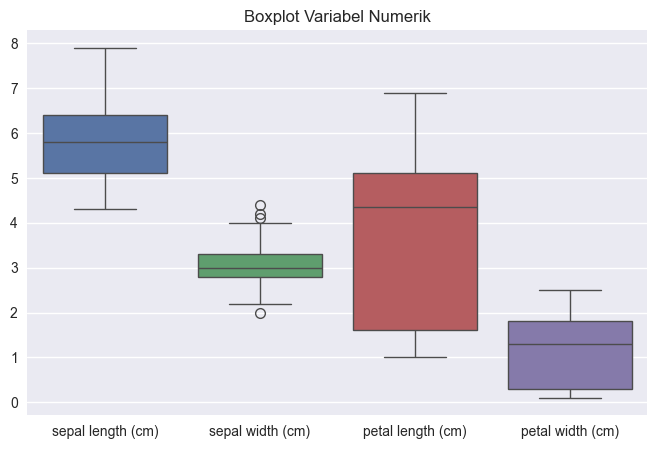

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df.iloc[:, :4])
plt.title("Boxplot Variabel Numerik")
plt.show()

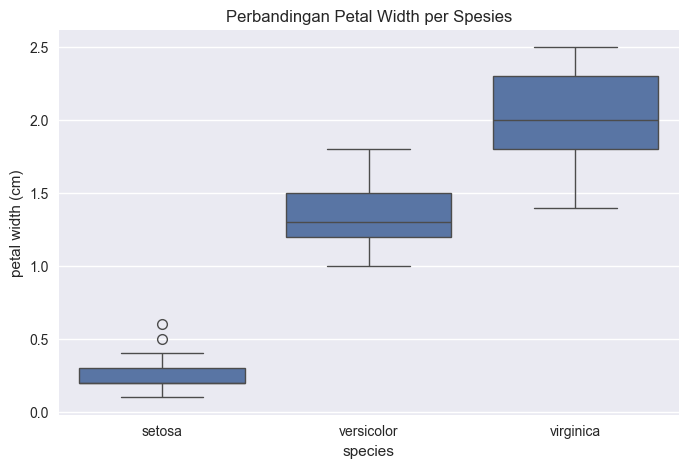

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x='species', y='petal width (cm)', data=df)
plt.title("Perbandingan Petal Width per Spesies")
plt.show()

### Insight Awal:
- Petal width dan petal length memiliki variasi besar.
- Setosa memiliki ukuran petal paling kecil.
- Virginica memiliki ukuran terbesar.
- Sepal width menunjukkan beberapa outlier.

# BAGIAN B – Bootstrap Sampling
Variabel yang digunakan: Petal Width (cm)

In [24]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

# Load data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Ambil variabel petal width
data = df["petal width (cm)"].values

# Set seed
np.random.seed(42)

# Jumlah bootstrap
n = len(data)
n_bootstrap = 1000

# Simpan hasil mean bootstrap
bootstrap_means = []

for i in range(n_bootstrap):
    sample = np.random.choice(data, size=n, replace=True)
    bootstrap_means.append(np.mean(sample))

# Hitung hasil
mean_asli = np.mean(data)
mean_bootstrap = np.mean(bootstrap_means)

median_asli = np.median(data)
median_bootstrap = np.median(bootstrap_means)

print("Mean asli:", mean_asli)
print("Mean bootstrap (rata-rata dari 1000 sampel):", mean_bootstrap)

print("Median asli:", median_asli)
print("Median bootstrap (median dari 1000 sampel):", median_bootstrap)

Mean asli: 1.1993333333333336
Mean bootstrap (rata-rata dari 1000 sampel): 1.2014353333333334
Median asli: 1.3
Median bootstrap (median dari 1000 sampel): 1.2006666666666665


In [28]:
import numpy as np

def bootstrap_mean(data, n_bootstrap, random_state=None):
    # Ubah ke numpy array biar aman
    data = np.array(data)
    
    # Set random seed kalau ada
    if random_state is not None:
        np.random.seed(random_state)
    
    n = len(data)
    
    means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        means.append(np.mean(sample))
        
    return np.array(means)

# Jalankan bootstrap
boot_100 = bootstrap_mean(data, 100, random_state=42)
boot_1000 = bootstrap_mean(data, 1000, random_state=42)
boot_10000 = bootstrap_mean(data, 10000, random_state=42)

print("Mean asli:", np.mean(data))
print("Mean bootstrap 100:", np.mean(boot_100))
print("Mean bootstrap 1000:", np.mean(boot_1000))
print("Mean bootstrap 10000:", np.mean(boot_10000))

Mean asli: 1.1993333333333336
Mean bootstrap 100: 1.2012333333333334
Mean bootstrap 1000: 1.2014353333333334
Mean bootstrap 10000: 1.1982283999999999


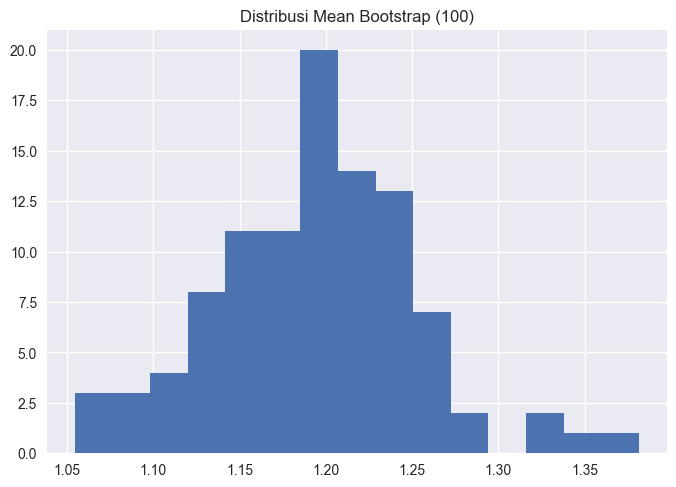

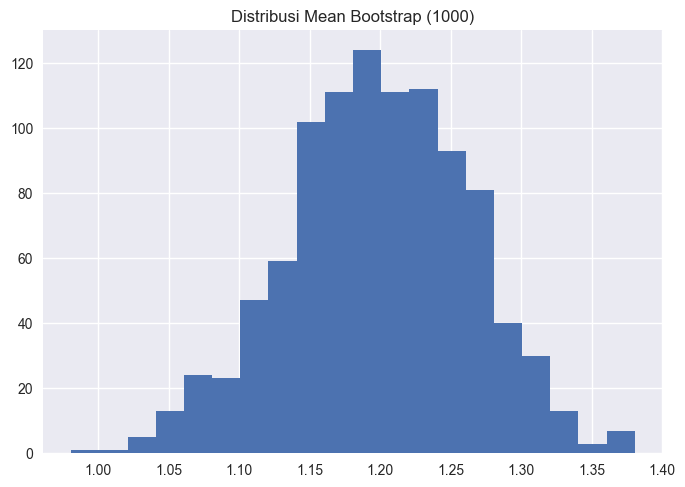

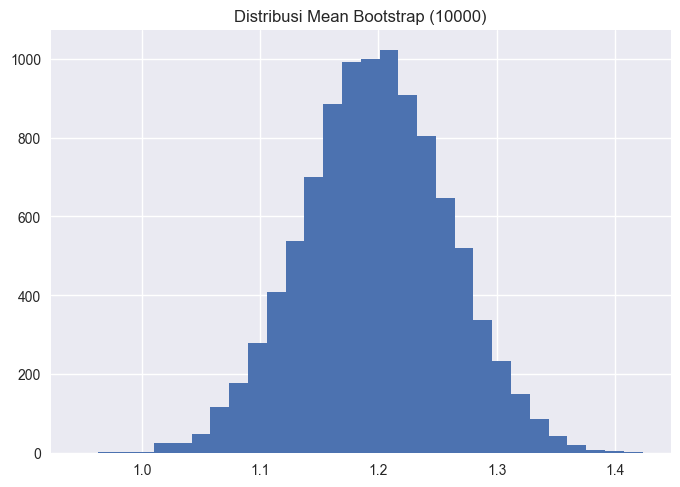

In [26]:
plt.hist(boot_100, bins=15)
plt.title("Distribusi Mean Bootstrap (100)")
plt.show()

plt.hist(boot_1000, bins=20)
plt.title("Distribusi Mean Bootstrap (1000)")
plt.show()

plt.hist(boot_10000, bins=30)
plt.title("Distribusi Mean Bootstrap (10000)")
plt.show()

In [27]:
def confidence_interval(data):
    return np.percentile(data, 2.5), np.percentile(data, 97.5)

ci_100 = confidence_interval(boot_100)
ci_1000 = confidence_interval(boot_1000)
ci_10000 = confidence_interval(boot_10000)

print("CI 100:", ci_100)
print("CI 1000:", ci_1000)
print("CI 10000:", ci_10000)

CI 100: (np.float64(1.0774833333333333), np.float64(1.3321333333333334))
CI 1000: (np.float64(1.0653166666666665), np.float64(1.316066666666667))
CI 10000: (np.float64(1.076), np.float64(1.32))


## Analisis

1. Mean bootstrap mendekati mean asli karena bootstrap merepresentasikan distribusi asli.
2. Semakin banyak bootstrap, distribusi semakin halus dan stabil.
3. 10000 bootstrap paling stabil.
4. Mean asli berada dalam interval kepercayaan 95%.
5. Data bisa muncul berkali-kali karena sampling dilakukan dengan pengembalian.

# Kesimpulan

- Fitur petal sangat efektif membedakan spesies.
- Setosa paling mudah dipisahkan.
- Bootstrap membantu mengestimasi distribusi mean tanpa asumsi normalitas.
- Minimal 1000 bootstrap sudah cukup stabil.